# Subgroup EDA: Oncology · Acute MI · Sepsis · Age Groups
Candidate subsets for foundation model vs traditional ML experiments.
Key question: where does small-N + MNAR missingness create the clearest advantage for TabPFN/ConTextTab?

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

REPO = next(p for p in [Path('../../').resolve(), *Path('../../').resolve().parents]
            if (p / 'pyproject.toml').exists())
load_dotenv(REPO / '.env')

def _resolve(env_var):
    p = Path(os.environ[env_var])
    return p if p.is_absolute() else REPO / p

ED   = _resolve('MIMIC_ED_DATA_PATH')
HOSP = _resolve('MIMIC_HOSP_DATA_PATH')
ICU  = _resolve('MIMIC_ICU_DATA_PATH')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette()
SUBGROUP_COLORS = {
    'Full cohort':        COLORS[7],
    'Active cancer tx':   COLORS[2],
    'Acute MI':           COLORS[3],
    'Sepsis':             COLORS[1],
    'Geriatric ESI 1+2':  COLORS[9],
    'Age 18-44':          COLORS[0],
    'Age 45-64':          COLORS[4],
    'Age 65-74':          COLORS[5],
    'Age 75-84':          COLORS[6],
    'Age 85-89':          COLORS[7],
    'Age 90+':            COLORS[8],
}
print(f'Repo root: {REPO}')
print(f'ED path:   {ED}')
print('Starting data load...')

Repo root: /Users/mikavohl/Projects/deep-learning-imputation
ED path:   /Users/mikavohl/Projects/deep-learning-imputation/data/mimic/new_mimic_iv_ed/physionet.org/files/mimic-iv-ed/2.2/ed
Starting data load...


## Load base tables

In [2]:
edstays   = pd.read_csv(ED / 'edstays.csv.gz')
triage    = pd.read_csv(ED / 'triage.csv.gz')
medrecon  = pd.read_csv(ED / 'medrecon.csv.gz')
patients  = pd.read_csv(HOSP / 'patients.csv.gz')
diagnoses = pd.read_csv(HOSP / 'diagnoses_icd.csv.gz')
admissions= pd.read_csv(HOSP / 'admissions.csv.gz', usecols=['hadm_id','hospital_expire_flag'])

TRIAGE_VITALS = ['temperature','heartrate','resprate','o2sat','sbp','dbp','pain','acuity']

# Coerce vitals to numeric — raw CSV can contain text entries (e.g. pain scores like "unable")
for col in TRIAGE_VITALS:
    triage[col] = pd.to_numeric(triage[col], errors='coerce')

ed = (
    edstays
    .merge(triage[['stay_id'] + TRIAGE_VITALS + ['chiefcomplaint']], on='stay_id', how='left')
    .merge(patients[['subject_id','anchor_age','anchor_year']], on='subject_id', how='left')
    .merge(admissions, on='hadm_id', how='left')
)

ed['intime']  = pd.to_datetime(ed['intime'])
ed['outtime'] = pd.to_datetime(ed['outtime'])
ed['los_hrs'] = (ed['outtime'] - ed['intime']).dt.total_seconds() / 3600
ed['approx_age'] = pd.to_numeric(ed['anchor_age'], errors='coerce') + \
                   (ed['intime'].dt.year - pd.to_numeric(ed['anchor_year'], errors='coerce'))

ed = ed[ed['los_hrs'] > 0].copy()

print(f'Master ED dataframe: {len(ed):,} stays')
ed[TRIAGE_VITALS + ['los_hrs','approx_age']].describe().round(2)

Master ED dataframe: 425,028 stays


,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,los_hrs,approx_age
count,401637.00,407960.00,404697.00,404454.00,406760.00,405960.00,396934.00,418052.00,425028.00,424952.00
mean,98.02,85.08,17.57,98.47,135.40,81.26,4.43,2.63,7.16,52.87
std,4.01,18.04,5.49,17.04,240.97,1057.27,4.09,0.71,6.63,20.62
min,0.10,1.00,0.00,0.00,1.00,0.00,-1.00,1.00,0.02,18.00
25%,97.50,72.00,16.00,97.00,120.00,68.00,0.00,2.00,3.53,35.00
50%,98.00,84.00,18.00,99.00,133.00,77.00,5.00,3.00,5.47,53.00
75%,98.60,96.00,18.00,100.00,148.00,87.00,8.00,3.00,8.32,69.00
max,986.00,1228.00,1820.00,9322.00,151103.00,661672.00,180.00,5.00,493.07,103.00


## Define subgroups

In [3]:
admitted_hadm = set(ed.dropna(subset=['hadm_id'])['hadm_id'])
diag_primary  = diagnoses[(diagnoses['hadm_id'].isin(admitted_hadm)) & (diagnoses['seq_num'] == 1)].copy()

def stays_with_icd_prefix(prefix):
    if isinstance(prefix, str):
        mask = diag_primary['icd_code'].str.startswith(prefix)
    else:
        mask = diag_primary['icd_code'].str[:len(prefix[0])].isin(set(prefix))
    hadm_ids = set(diag_primary[mask]['hadm_id'])
    return set(ed[ed['hadm_id'].isin(hadm_ids)]['stay_id'])

# Active cancer treatment (cleaned medrecon — excludes RA/sickle cell/IBD drugs)
_EXCLUDED_CLASSES = {
    "Antineoplastic - Antimetabolite - Folic Acid Analogs",
    "Antineoplastic - Antimetabolite - Urea Derivatives",
    "Antineoplastic - Antimetabolite - Purine Analogs",
    "Dermatological - Antineoplastic Antimetabolites",
    "Dermatological - Antineoplastic or Premalignant Lesions - NSAID's",
    "Antineoplastic - Mast Cell Stabilizers",
    "Antineoplastic - Progestins",
}
_is_antineopl = medrecon['etcdescription'].str.lower().str.contains('antineoplast', na=False)
_is_excluded  = medrecon['etcdescription'].isin(_EXCLUDED_CLASSES)
cancer_stay_ids = set(medrecon[_is_antineopl & ~_is_excluded]['stay_id'])

# Acute MI: ICD-10 I21.* primary dx (admitted)
ami_stay_ids = stays_with_icd_prefix('I21')

# Sepsis: ICD-10 A41.* primary dx (admitted)
sepsis_stay_ids = stays_with_icd_prefix('A41')

# Geriatric high-acuity: age ≥75 AND ESI 1 or 2 — both filters observable at triage
geri_esi_stay_ids = set(
    ed[(ed['approx_age'] >= 75) & ed['acuity'].isin([1.0, 2.0])]['stay_id']
)

# Age bands
age_bands = {
    'Age 18-44': (18, 45),
    'Age 45-64': (45, 65),
    'Age 65-74': (65, 75),
    'Age 75-84': (75, 85),
    'Age 85-89': (85, 90),
    'Age 90+':   (90, 150),
}

subgroups = {
    'Full cohort':        ed['stay_id'],
    'Active cancer tx':   ed[ed['stay_id'].isin(cancer_stay_ids)]['stay_id'],
    'Acute MI':           ed[ed['stay_id'].isin(ami_stay_ids)]['stay_id'],
    'Sepsis':             ed[ed['stay_id'].isin(sepsis_stay_ids)]['stay_id'],
    'Geriatric ESI 1+2':  ed[ed['stay_id'].isin(geri_esi_stay_ids)]['stay_id'],
    **{label: ed[(ed['approx_age'] >= lo) & (ed['approx_age'] < hi)]['stay_id']
       for label, (lo, hi) in age_bands.items()},
}

for name, ids in subgroups.items():
    print(f'{name:<20}: {len(ids):>7,}')

Full cohort         : 425,028
Active cancer tx    :   5,557
Acute MI            :   1,672
Sepsis              :   4,308
Geriatric ESI 1+2   :  39,584
Age 18-44           : 155,518
Age 45-64           : 136,061
Age 65-74           :  59,736
Age 75-84           :  42,960
Age 85-89           :  16,473
Age 90+             :  14,204


### How each subgroup is determined

| Subgroup | Source table | Filter logic | Leakage risk |
|---|---|---|---|
| **Full cohort** | `edstays` | All ED visits | — |
| **Oncology** | `ed/medrecon` | Any antineoplastic drug in home med list at triage (`etcdescription` contains `"antineoplast"`) | None — home meds are documented at arrival, before the visit outcome is known |
| **Acute MI** | `hosp/diagnoses_icd` | Primary ICD-10 diagnosis starts with `I21` (acute myocardial infarction), admitted patients only | Mild — diagnosis is assigned at discharge, so the subset is only knowable in retrospect. Suitable for retrospective analysis. |
| **Sepsis** | `hosp/diagnoses_icd` | Primary ICD-10 diagnosis starts with `A41` (other sepsis), admitted patients only | Same as above |
| **Age bands** | `hosp/patients` | `approx_age = anchor_age + (intime_year − anchor_year)`. MIMIC shifts each patient's timeline by a random offset to de-identify dates, so `anchor_age` is the true age at `anchor_year`. Ages are capped at 91 for privacy. | None |

**Note on ICD-based subgroups**: the primary diagnosis filter uses only admitted patients (those with a `hadm_id`). This means Acute MI and Sepsis are pre-selected for severity — they were sick enough to be admitted. The oncology filter via medrecon covers the full ED population including discharged patients.

## 1. Subgroup sizes

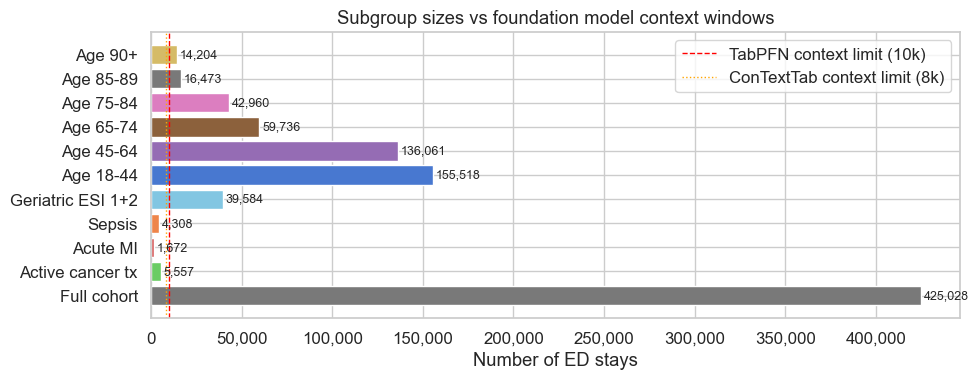

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
names  = list(subgroups.keys())
sizes  = [len(v) for v in subgroups.values()]
colors = [SUBGROUP_COLORS[n] for n in names]

bars = ax.barh(names, sizes, color=colors, edgecolor='white')
ax.axvline(10_000, color='red', linestyle='--', linewidth=1, label='TabPFN context limit (10k)')
ax.axvline(8_192,  color='orange', linestyle=':', linewidth=1, label='ConTextTab context limit (8k)')
for bar, n in zip(bars, sizes):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center', fontsize=9)
ax.set_xlabel('Number of ED stays')
ax.set_title('Subgroup sizes vs foundation model context windows')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 2. Missingness in triage vitals

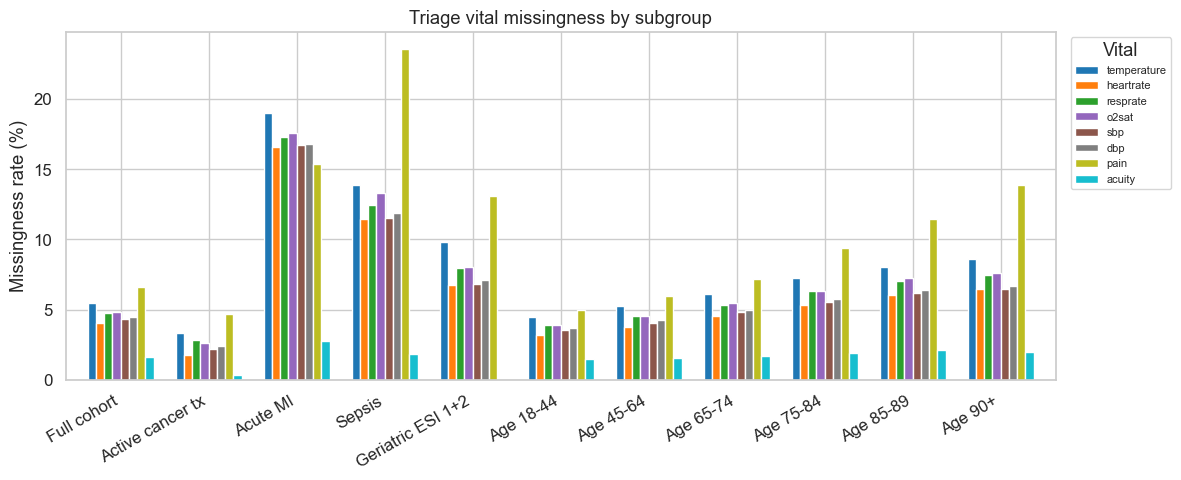

,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity
Full cohort,5.5,4.0,4.8,4.8,4.3,4.5,6.6,1.6
Active cancer tx,3.4,1.8,2.8,2.6,2.2,2.4,4.7,0.4
Acute MI,19.0,16.6,17.3,17.6,16.7,16.8,15.4,2.8
Sepsis,13.9,11.4,12.5,13.3,11.5,11.9,23.6,1.8
Geriatric ESI 1+2,9.8,6.7,8.0,8.1,6.8,7.1,13.1,0.0
Age 18-44,4.5,3.2,3.9,3.9,3.6,3.7,5.0,1.5
Age 45-64,5.2,3.8,4.5,4.6,4.1,4.3,6.0,1.6
Age 65-74,6.1,4.6,5.3,5.5,4.8,5.0,7.2,1.7
Age 75-84,7.3,5.3,6.3,6.3,5.5,5.7,9.4,1.9
Age 85-89,8.0,6.1,7.0,7.2,6.2,6.4,11.5,2.1


In [5]:
def missingness_rate(stay_ids, cols=TRIAGE_VITALS):
    sub = ed[ed['stay_id'].isin(stay_ids)]
    return sub[cols].isna().mean() * 100

miss_df = pd.DataFrame(
    {name: missingness_rate(ids) for name, ids in subgroups.items()}
).T

fig, ax = plt.subplots(figsize=(12, 5))
miss_df.plot(kind='bar', ax=ax, colormap='tab10', width=0.75, edgecolor='white')
ax.set_ylabel('Missingness rate (%)')
ax.set_title('Triage vital missingness by subgroup')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Vital', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

miss_df.round(1)

## 3. LOS distribution by subgroup

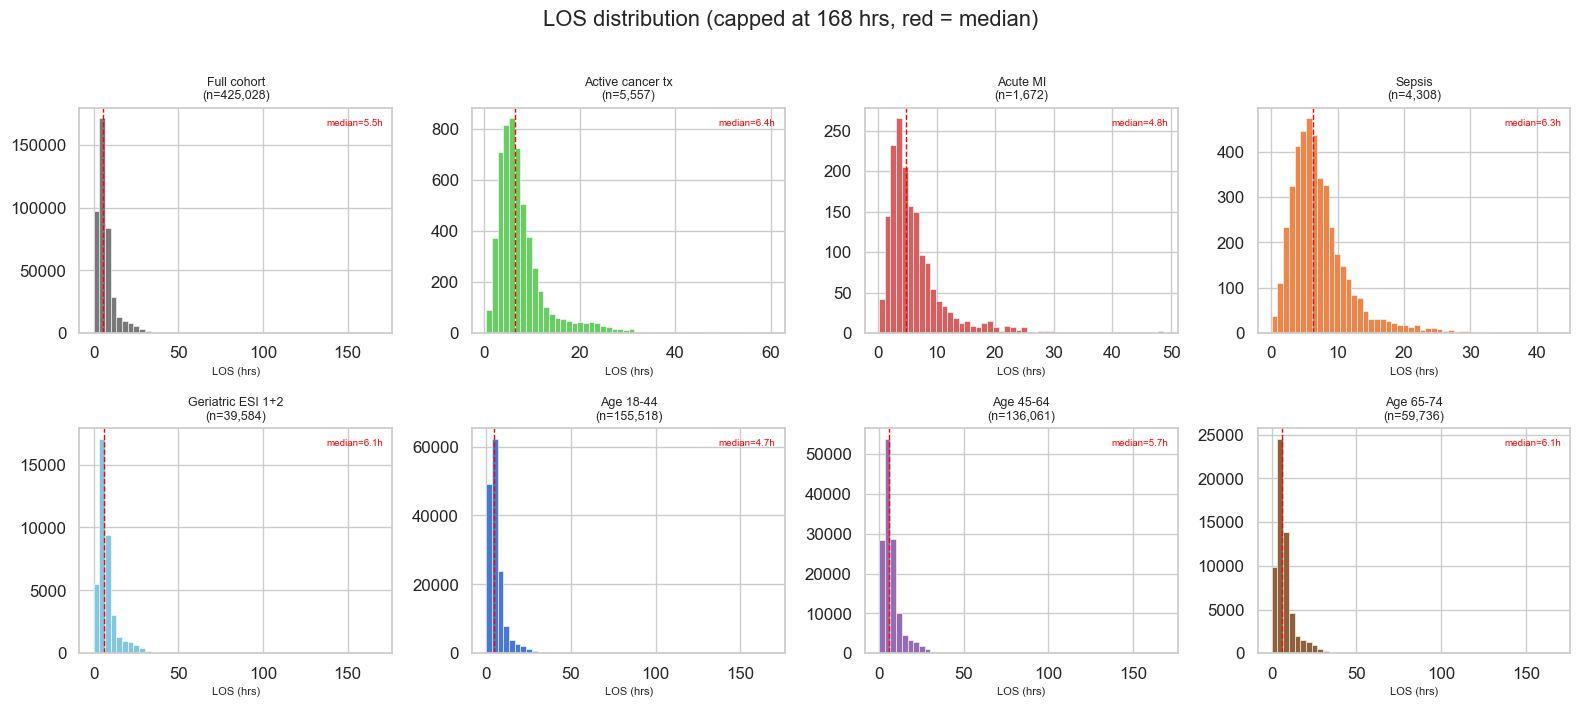

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, (name, ids) in zip(axes, subgroups.items()):
    sub = ed[ed['stay_id'].isin(ids)]['los_hrs'].clip(upper=168)  # cap at 1 week
    ax.hist(sub, bins=50, color=SUBGROUP_COLORS[name], edgecolor='white', linewidth=0.4)
    ax.set_title(f'{name}\n(n={len(ids):,})', fontsize=9)
    ax.set_xlabel('LOS (hrs)', fontsize=8)
    ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)
    ax.text(0.97, 0.95, f'median={sub.median():.1f}h', transform=ax.transAxes,
            ha='right', va='top', fontsize=7, color='red')

plt.suptitle('LOS distribution (capped at 168 hrs, red = median)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Mortality rate by subgroup

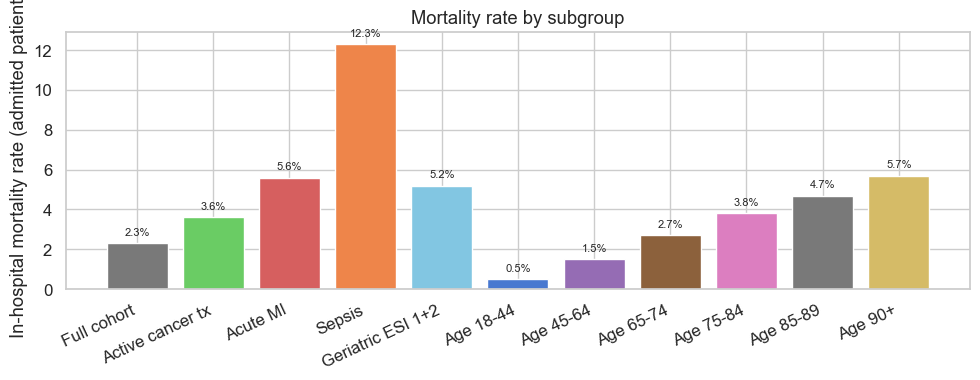

,n_total,n_admitted,n_died,mortality_%
Full cohort,425028.0,202990.0,4605.0,2.3
Active cancer tx,5557.0,3798.0,137.0,3.6
Acute MI,1672.0,1672.0,94.0,5.6
Sepsis,4308.0,4308.0,528.0,12.3
Geriatric ESI 1+2,39584.0,32918.0,1724.0,5.2
Age 18-44,155518.0,45474.0,250.0,0.5
Age 45-64,136061.0,67770.0,1046.0,1.5
Age 65-74,59736.0,37047.0,1007.0,2.7
Age 75-84,42960.0,29756.0,1117.0,3.8
Age 85-89,16473.0,12123.0,566.0,4.7


In [7]:
mort_rates = {}
for name, ids in subgroups.items():
    sub = ed[ed['stay_id'].isin(ids)]
    n_admitted = sub['hospital_expire_flag'].notna().sum()
    n_died = sub['hospital_expire_flag'].sum()
    mort_rates[name] = {
        'n_total': len(sub),
        'n_admitted': int(n_admitted),
        'n_died': int(n_died),
        'mortality_%': round(n_died / n_admitted * 100, 1) if n_admitted > 0 else 0,
    }

mort_df = pd.DataFrame(mort_rates).T

fig, ax = plt.subplots(figsize=(10, 4))
colors = [SUBGROUP_COLORS[n] for n in mort_df.index]
bars = ax.bar(mort_df.index, mort_df['mortality_%'], color=colors, edgecolor='white')
for bar, (_, row) in zip(bars, mort_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{row['mortality_%']:.1f}%", ha='center', va='bottom', fontsize=8)
ax.set_ylabel('In-hospital mortality rate (admitted patients)')
ax.set_title('Mortality rate by subgroup')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()

mort_df

## 5. Triage vital distributions — subgroups vs full cohort

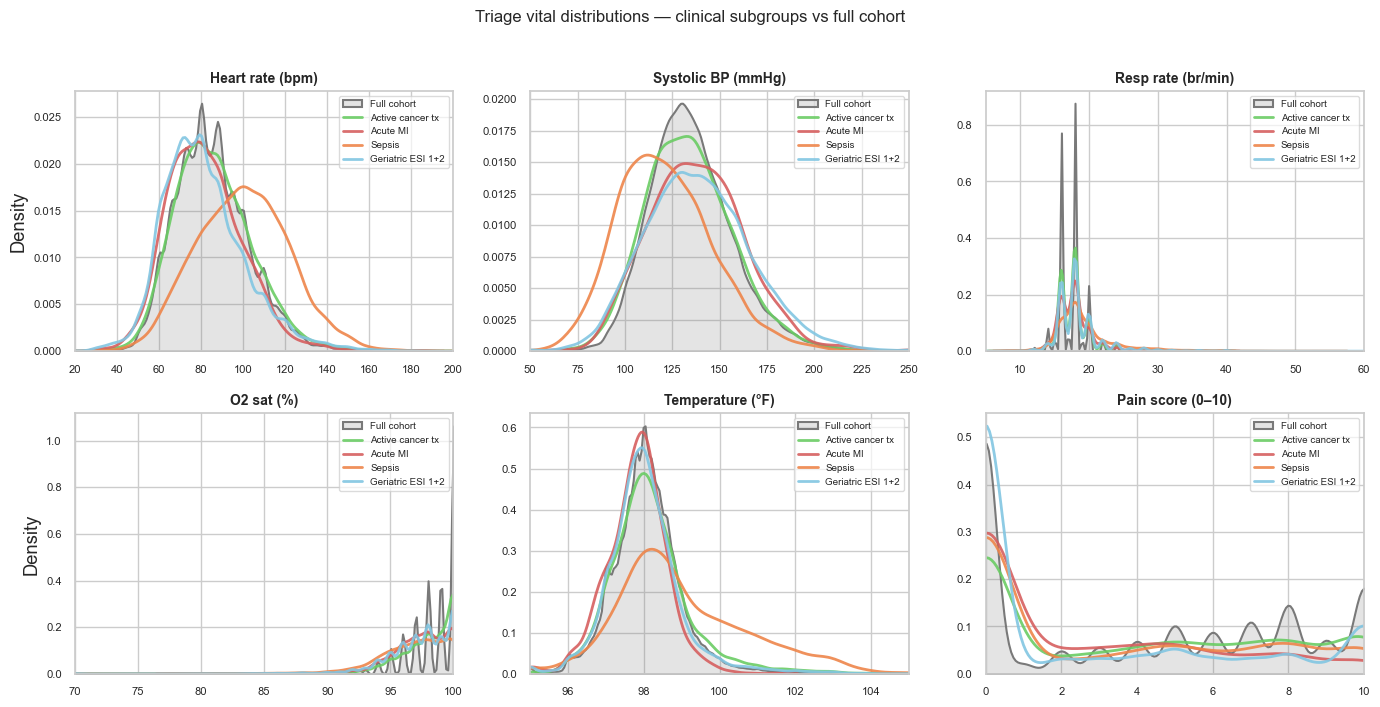

In [8]:
FOCUS = ['Active cancer tx', 'Acute MI', 'Sepsis', 'Geriatric ESI 1+2']
VITALS_PLOT = ['heartrate', 'sbp', 'resprate', 'o2sat', 'temperature', 'pain']
VITAL_LABELS = {
    'heartrate':   'Heart rate (bpm)',
    'sbp':         'Systolic BP (mmHg)',
    'resprate':    'Resp rate (br/min)',
    'o2sat':       'O2 sat (%)',
    'temperature': 'Temperature (°F)',
    'pain':        'Pain score (0–10)',
}
VITAL_CLIP = {
    'heartrate':   (20, 200),
    'sbp':         (50, 250),
    'resprate':    (5,  60),
    'o2sat':       (70, 100),
    'temperature': (95, 105),
    'pain':        (0,  10),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, vital in zip(axes, VITALS_PLOT):
    lo, hi = VITAL_CLIP[vital]
    full_data = ed[vital].dropna().clip(lo, hi)

    sns.kdeplot(full_data, ax=ax, fill=True, alpha=0.2,
                color=SUBGROUP_COLORS['Full cohort'], label='Full cohort', linewidth=1.5)

    for name in FOCUS:
        sub_data = ed[ed['stay_id'].isin(subgroups[name])][vital].dropna().clip(lo, hi)
        if len(sub_data) < 10:
            continue
        sns.kdeplot(sub_data, ax=ax, fill=False, alpha=0.9,
                    color=SUBGROUP_COLORS[name], label=name, linewidth=2)

    ax.set_title(VITAL_LABELS[vital], fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density' if vital in ('heartrate', 'o2sat') else '')
    ax.set_xlim(lo, hi)
    ax.legend(fontsize=7, framealpha=0.7)
    ax.tick_params(labelsize=8)

plt.suptitle('Triage vital distributions — clinical subgroups vs full cohort', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Acuity (ESI) distribution

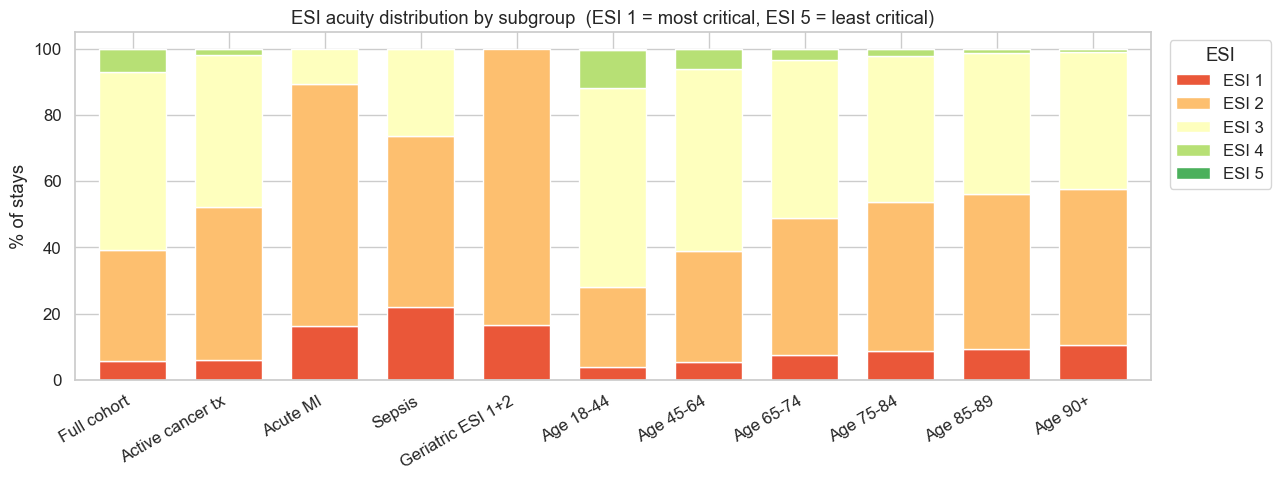

,ESI 1,ESI 2,ESI 3,ESI 4,ESI 5
Full cohort,5.7,33.3,53.8,6.8,0.3
Active cancer tx,6.1,46.1,45.9,1.9,0.0
Acute MI,16.2,72.9,10.8,0.0,0.0
Sepsis,22.1,51.4,26.3,0.1,0.0
Geriatric ESI 1+2,16.7,83.3,0.0,0.0,0.0
Age 18-44,3.8,24.3,60.2,11.3,0.5
Age 45-64,5.4,33.5,54.9,5.9,0.2
Age 65-74,7.4,41.4,47.6,3.4,0.1
Age 75-84,8.6,45.0,44.3,2.1,0.1
Age 85-89,9.4,46.5,42.7,1.3,0.1


In [9]:
esi_data = {}
for name, ids in subgroups.items():
    sub = ed[ed['stay_id'].isin(ids)]
    esi_counts = sub['acuity'].value_counts(normalize=True).sort_index() * 100
    esi_data[name] = esi_counts

esi_df = pd.DataFrame(esi_data).fillna(0).T
esi_df.columns = [f'ESI {int(c)}' for c in esi_df.columns]

# ESI 1 = most critical → red; ESI 5 = least critical → green
# RdYlGn (not reversed): index 0 = red → ESI 1, index 4 = green → ESI 5
esi_colors = sns.color_palette('RdYlGn', 5)

fig, ax = plt.subplots(figsize=(13, 5))
esi_df.plot(kind='bar', ax=ax, stacked=True,
            color=esi_colors, edgecolor='white', width=0.7)
ax.set_ylabel('% of stays')
ax.set_title('ESI acuity distribution by subgroup  (ESI 1 = most critical, ESI 5 = least critical)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='ESI', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

esi_df.round(1)

## 7. Age distribution

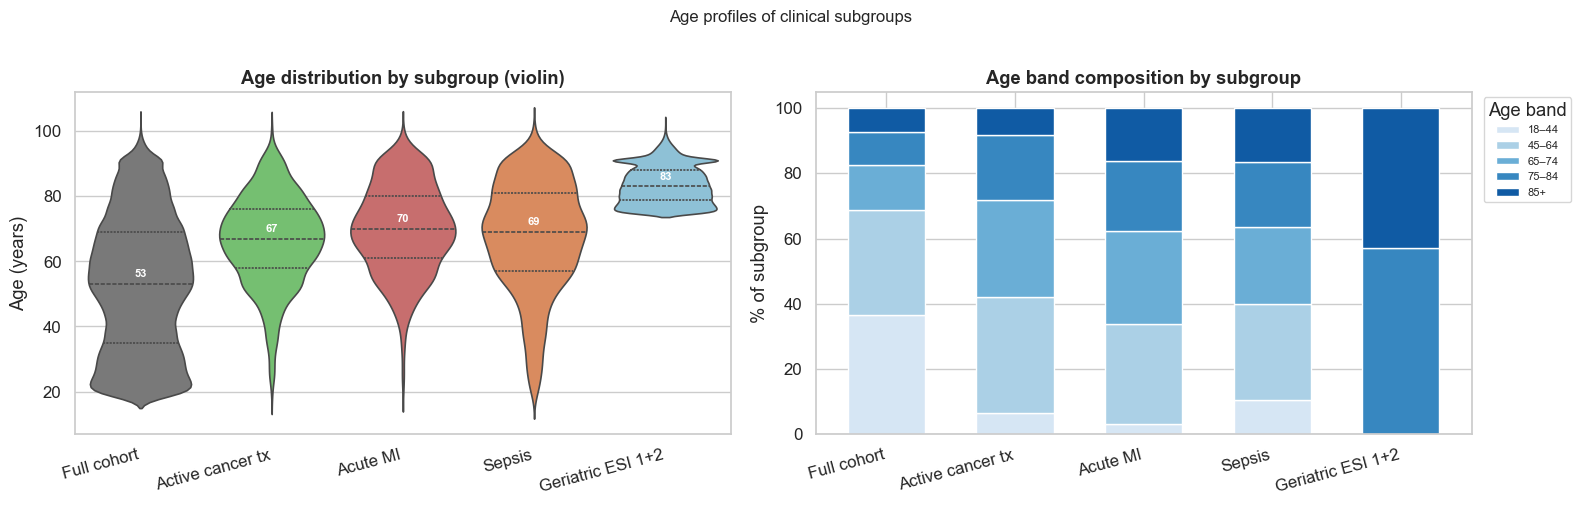

In [10]:
FOCUS_AGE = ['Full cohort', 'Active cancer tx', 'Acute MI', 'Sepsis', 'Geriatric ESI 1+2']

age_rows = []
for name in FOCUS_AGE:
    ages = ed[ed['stay_id'].isin(subgroups[name])]['approx_age'].dropna()
    age_rows.append(pd.DataFrame({'subgroup': name, 'age': ages}))
age_long = pd.concat(age_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: violin
ax = axes[0]
palette = {n: SUBGROUP_COLORS[n] for n in FOCUS_AGE}
sns.violinplot(data=age_long, x='subgroup', y='age', order=FOCUS_AGE,
               palette=palette, inner='quartile', linewidth=1.2, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Age (years)')
ax.set_title('Age distribution by subgroup (violin)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
for i, name in enumerate(FOCUS_AGE):
    med = age_long[age_long['subgroup'] == name]['age'].median()
    ax.text(i, med + 1.5, f'{med:.0f}', ha='center', va='bottom',
            fontsize=8, color='white', fontweight='bold')

# Right: stacked age-band proportions
ax2 = axes[1]
bands = [('18–44', 18, 45), ('45–64', 45, 65), ('65–74', 65, 75), ('75–84', 75, 85), ('85+', 85, 999)]
band_data = {}
for name in FOCUS_AGE:
    ages = ed[ed['stay_id'].isin(subgroups[name])]['approx_age'].dropna()
    band_data[name] = {label: ((ages >= lo) & (ages < hi)).mean() * 100
                       for label, lo, hi in bands}
band_df = pd.DataFrame(band_data).T
band_df.plot(kind='bar', stacked=True, ax=ax2,
             color=sns.color_palette('Blues', len(bands)), edgecolor='white', width=0.6)
ax2.set_ylabel('% of subgroup')
ax2.set_title('Age band composition by subgroup', fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15, ha='right')
ax2.legend(title='Age band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Age profiles of clinical subgroups', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. Missingness heatmap

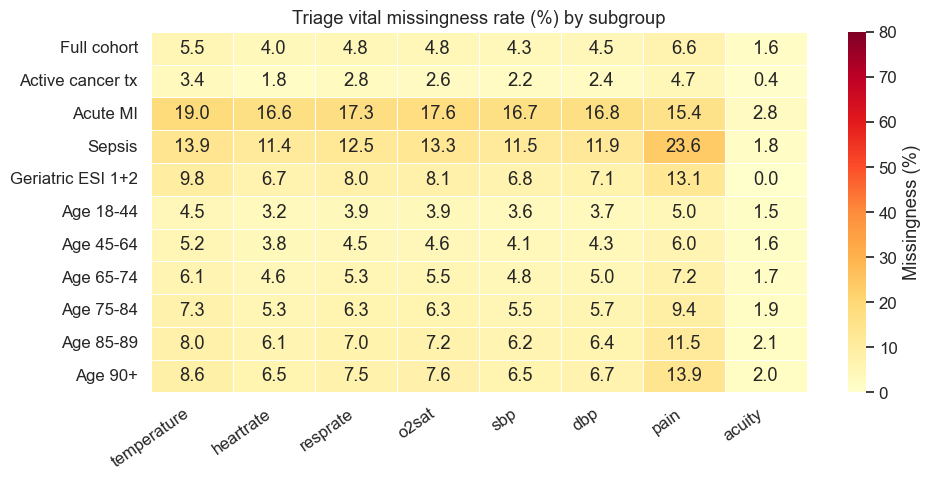

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    miss_df,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Missingness (%)'},
    vmin=0, vmax=80
)
ax.set_title('Triage vital missingness rate (%) by subgroup')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 9. LOS summary statistics

In [12]:
los_stats = {}
for name, ids in subgroups.items():
    los = ed[ed['stay_id'].isin(ids)]['los_hrs']
    los_stats[name] = {
        'n': len(los),
        'mean': round(los.mean(), 1),
        'median': round(los.median(), 1),
        'p25': round(los.quantile(0.25), 1),
        'p75': round(los.quantile(0.75), 1),
        'p90': round(los.quantile(0.90), 1),
        '>24h (%)': round((los > 24).mean() * 100, 1),
        '>72h (%)': round((los > 72).mean() * 100, 1),
    }

pd.DataFrame(los_stats).T

,n,mean,median,p25,p75,p90,>24h (%),>72h (%)
Full cohort,425028.0,7.2,5.5,3.5,8.3,13.6,2.8,0.1
Active cancer tx,5557.0,7.9,6.4,4.4,9.1,14.2,2.8,0.0
Acute MI,1672.0,6.2,4.8,3.1,7.6,11.8,1.1,0.0
Sepsis,4308.0,7.3,6.3,4.3,9.0,12.7,1.3,0.0
Geriatric ESI 1+2,39584.0,7.8,6.1,4.3,8.9,14.8,3.3,0.0
Age 18-44,155518.0,6.3,4.6,2.9,7.2,11.7,2.2,0.1
Age 45-64,136061.0,7.4,5.7,3.7,8.7,14.2,2.8,0.1
Age 65-74,59736.0,7.7,6.1,4.1,9.0,14.7,3.2,0.0
Age 75-84,42960.0,7.9,6.2,4.2,9.0,15.2,3.8,0.0
Age 85-89,16473.0,8.0,6.2,4.3,9.0,15.5,3.7,0.0


## 10. Disposition breakdown

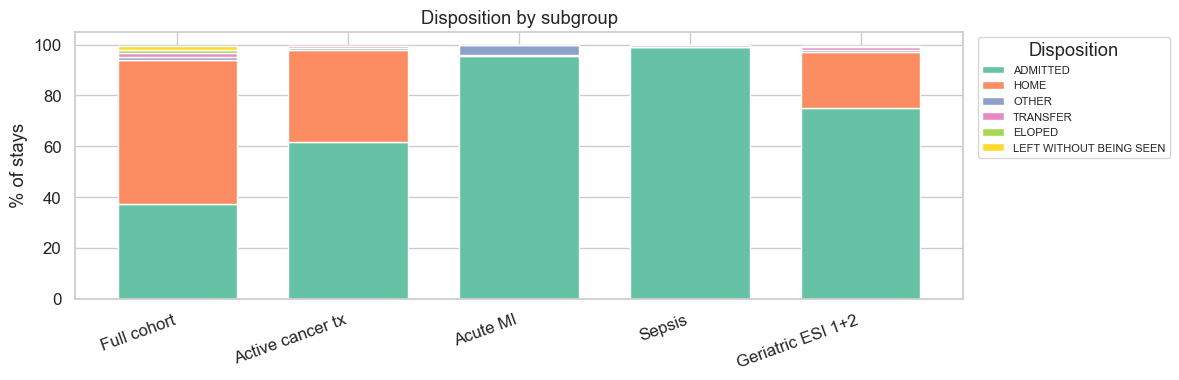

disposition,ADMITTED,HOME,OTHER,TRANSFER,ELOPED,LEFT WITHOUT BEING SEEN
Full cohort,37.2,56.8,1.0,1.7,1.3,1.4
Active cancer tx,61.7,36.4,0.5,0.7,0.3,0.0
Acute MI,95.6,0.3,3.9,0.1,0.0,0.1
Sepsis,98.9,0.2,0.7,0.0,0.0,0.0
Geriatric ESI 1+2,74.9,22.2,0.9,1.2,0.1,0.2


In [13]:
FOCUS_DISP = ['Full cohort', 'Active cancer tx', 'Acute MI', 'Sepsis', 'Geriatric ESI 1+2']

disp_data = {}
for name in FOCUS_DISP:
    ids = subgroups[name]
    sub = ed[ed['stay_id'].isin(ids)]
    disp = sub['disposition'].str.upper().value_counts(normalize=True) * 100
    disp_data[name] = disp

disp_df = pd.DataFrame(disp_data).fillna(0).T
top_disp = disp_df.mean().nlargest(6).index
disp_df  = disp_df[top_disp]

fig, ax = plt.subplots(figsize=(12, 4))
disp_df.plot(kind='bar', ax=ax, stacked=True,
             color=sns.color_palette('Set2', len(top_disp)), edgecolor='white', width=0.7)
ax.set_ylabel('% of stays')
ax.set_title('Disposition by subgroup')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Disposition', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

disp_df.round(1)